# MedBoard — Train EfficientNet-B0 Classification Model

**Run this notebook either locally or in Google Colab to train the tumor classifier.**

### What this notebook does:
1. **Environment Setup**: Auto-detects Colab vs. Local VS Code; sets paths and dependencies.
2. **Dataset Loading**: Loads BRISC 2025 images for 4 classes (`glioma`, `meningioma`, `no_tumor`, `pituitary`) with stratified train/validation split (85%/15%) and data augmentations.
3. **Model Initialization**: Instantiates an ImageNet-pretrained **EfficientNet-B0** (~4.01M parameters).
4. **Training**: Trains with AdamW, Cosine Annealing LR, FP16 mixed precision, and early stopping.
5. **Curve Visualization**: Plots Train/Val Loss and Accuracy over epochs.
6. **Test Evaluation**: Computes Test Accuracy, Macro-F1, Confusion Matrix, and Per-Class Report.
7. **Export**: Saves best model weights for the MedBoard multi-agent pipeline.

**Expected training time:** ~15–20 minutes on Colab T4 GPU (or ~25–35 minutes on RTX 2050 locally).

## Cell 1 — Environment Setup (Run Every Session)

In [1]:
import os, sys, shutil

# ── Detect environment ───────────────────────────────────────────────
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

print(f'Running in: {"Google Colab" if IS_COLAB else "Local (VS Code / Jupyter)"}')

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Clone or update MedBoard repo from GitHub
    if not os.path.exists('/content/MedBoard'):
        !git clone https://github.com/shivanshu0055/Medical-Image.git /content/MedBoard
    else:
        !git -C /content/MedBoard pull

    # Copy dataset from Google Drive to local Colab SSD for high-speed I/O
    if not os.path.exists('/content/data'):
        print('Copying dataset to local SSD (~30 sec)...')
        shutil.copytree('/content/drive/MyDrive/medboard/data/brisc2025', '/content/data')
        print('Dataset copied.')
    else:
        print('Dataset already available on local SSD.')

    # Install requirements
    !pip install -q -r /content/MedBoard/requirements_colab.txt

    sys.path.insert(0, '/content/MedBoard')
    DATA_ROOT   = '/content/data/classification_task'
    WEIGHTS_DIR = '/content/drive/MyDrive/medboard/weights'

else:
    # Local paths
    REPO_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.exists(os.path.join(os.getcwd(), '..', 'modules')) else os.getcwd()
    DATA_ROOT   = os.path.join(REPO_ROOT, 'data', 'raw', 'classification_task')
    WEIGHTS_DIR = os.path.join(REPO_ROOT, 'models', 'classification')

    if REPO_ROOT not in sys.path:
        sys.path.insert(0, REPO_ROOT)

os.makedirs(WEIGHTS_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, 'efficientnet_b0_best.pth')
FINAL_PATH      = os.path.join(WEIGHTS_DIR, 'efficientnet_b0_brisc.pth')

print('\nSetup complete!')
print(f'  Data Path    -> {DATA_ROOT}')
print(f'  Weights Path -> {WEIGHTS_DIR}')

Running in: Google Colab
Mounted at /content/drive
Cloning into '/content/MedBoard'...
remote: Enumerating objects: 203, done.
remote: Counting objects: 100% (203/203), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 203 (delta 93), reused 159 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (203/203), 3.17 MiB | 2.46 MiB/s, done.
Resolving deltas: 100% (93/93), done.
Copying dataset to local SSD (~30 sec)...
Dataset copied.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 132.7 MB

## Cell 2 — Verify Hardware & GPU Acceleration

In [2]:
import torch

print('=== PyTorch & Hardware Check ===')
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available:  {torch.cuda.is_available()}')

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU Device:      {gpu_name}')
    print(f'Total VRAM:      {vram_gb:.2f} GB')
    DEVICE_STR = 'cuda'
else:
    print('Running on CPU (training will be slower).')
    DEVICE_STR = 'cpu'

=== PyTorch & Hardware Check ===
PyTorch Version: 2.11.0+cu130
CUDA Available:  True
GPU Device:      Tesla T4
Total VRAM:      15.64 GB


## Cell 3 — Load BRISC 2025 Classification Data

In [3]:
from modules.clf_dataset import create_classification_dataloaders, DEFAULT_CLASSES

train_dir = os.path.join(DATA_ROOT, 'train')
test_dir  = os.path.join(DATA_ROOT, 'test')

print('Loading dataset from:', DATA_ROOT)
print('Target classes:', DEFAULT_CLASSES)

train_loader, val_loader, test_loader = create_classification_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    val_ratio=0.15,
    batch_size=32 if torch.cuda.is_available() else 8,
    image_size=224,
    num_workers=2 if IS_COLAB else 0,
    seed=42,
)

print(f'\nDataLoader Summary:')
print(f'  Train batches:      {len(train_loader)} ({len(train_loader.dataset)} images)')
print(f'  Validation batches: {len(val_loader)} ({len(val_loader.dataset)} images)')
print(f'  Test batches:       {len(test_loader)} ({len(test_loader.dataset)} images)')

# Check one batch shape
sample_images, sample_labels = next(iter(train_loader))
print(f'\nSample batch:')
print(f'  Images shape: {sample_images.shape} (B, C, H, W)')
print(f'  Labels shape: {sample_labels.shape}')

Loading dataset from: /content/data/classification_task
Target classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']

DataLoader Summary:
  Train batches:      131 (4192 images)
  Validation batches: 24 (740 images)
  Test batches:       31 (989 images)

Sample batch:
  Images shape: torch.Size([32, 3, 224, 224]) (B, C, H, W)
  Labels shape: torch.Size([32])


## Cell 4 — Initialize Pretrained EfficientNet-B0

In [4]:
from modules.classifier import build_classifier, count_parameters

model = build_classifier(
    num_classes=len(DEFAULT_CLASSES),
    pretrained=True,
    dropout_rate=0.2,
)

param_info = count_parameters(model)
print('EfficientNet-B0 Built Successfully!')
print(f'  Total Parameters:     {param_info["total"]:,}')
print(f'  Trainable Parameters: {param_info["trainable"]:,}')
print(f'  Estimated Size:       ~{param_info["total"] * 4 / (1024**2):.2f} MB')

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

EfficientNet-B0 Built Successfully!
  Total Parameters:     4,012,672
  Trainable Parameters: 4,012,672
  Estimated Size:       ~15.31 MB


## Cell 5 — Train Classifier (AdamW + Cosine Annealing + Early Stopping)

In [5]:
from modules.clf_trainer import train_classifier

# Hyperparameters
EPOCHS        = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 5

history = train_classifier(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    checkpoint_path=CHECKPOINT_PATH,
    device_str=DEVICE_STR,
    use_mixed_precision=True,
    class_names=DEFAULT_CLASSES,
)

Training on device: cuda
Starting training for 20 epochs...

Epoch 01/20 [LR: 0.000100]
  Train Loss: 1.3151 | Train Acc: 74.81%
  Val Loss:   0.6616 | Val Acc:   87.16% | Val Macro-F1: 0.8722
  Val loss improved: inf -> 0.6616. Saving checkpoint...

Epoch 02/20 [LR: 0.000099]
  Train Loss: 0.6365 | Train Acc: 88.24%
  Val Loss:   0.5227 | Val Acc:   90.54% | Val Macro-F1: 0.9050
  Val loss improved: 0.6616 -> 0.5227. Saving checkpoint...

Epoch 03/20 [LR: 0.000098]
  Train Loss: 0.4811 | Train Acc: 91.79%
  Val Loss:   0.3914 | Val Acc:   95.00% | Val Macro-F1: 0.9498
  Val loss improved: 0.5227 -> 0.3914. Saving checkpoint...

Epoch 04/20 [LR: 0.000095]
  Train Loss: 0.3993 | Train Acc: 94.51%
  Val Loss:   0.3583 | Val Acc:   95.00% | Val Macro-F1: 0.9502
  Val loss improved: 0.3914 -> 0.3583. Saving checkpoint...

Epoch 05/20 [LR: 0.000091]
  Train Loss: 0.3681 | Train Acc: 95.32%
  Val Loss:   0.3376 | Val Acc:   95.81% | Val Macro-F1: 0.9592
  Val loss improved: 0.3583 -> 0.3376.

## Cell 6 — Plot Training & Validation Curves

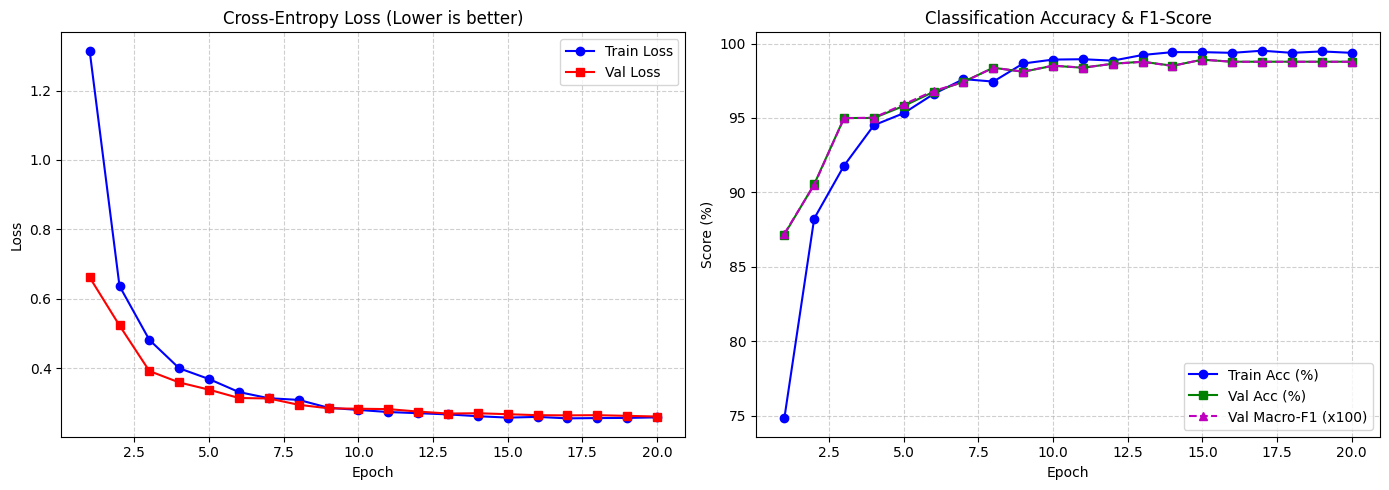

Training curves saved to: /content/drive/MyDrive/medboard/weights/clf_training_curves.png


In [6]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Curve
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss')
ax1.set_title('Cross-Entropy Loss (Lower is better)', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 2. Accuracy Curve
ax2.plot(epochs_range, [acc * 100 for acc in history['train_acc']], 'b-o', label='Train Acc (%)')
ax2.plot(epochs_range, [acc * 100 for acc in history['val_acc']], 'g-s', label='Val Acc (%)')
ax2.plot(epochs_range, [f1 * 100 for f1 in history['val_f1']], 'm--^', label='Val Macro-F1 (x100)')
ax2.set_title('Classification Accuracy & F1-Score', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score (%)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
curves_path = os.path.join(WEIGHTS_DIR, 'clf_training_curves.png')
plt.savefig(curves_path, dpi=200)
plt.show()
print(f'Training curves saved to: {curves_path}')

## Cell 7 — Test Set Evaluation (Confusion Matrix & Classification Report)

Evaluating best model on un-seen Test Set (1,000 images)...

TEST ACCURACY:  98.28%
TEST MACRO-F1:  0.9830
TEST LOSS:      0.0719

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.96      0.98       250
  meningioma       0.97      0.98      0.97       300
    no_tumor       0.97      1.00      0.99       140
   pituitary       0.99      1.00      0.99       299

    accuracy                           0.98       989
   macro avg       0.98      0.98      0.98       989
weighted avg       0.98      0.98      0.98       989



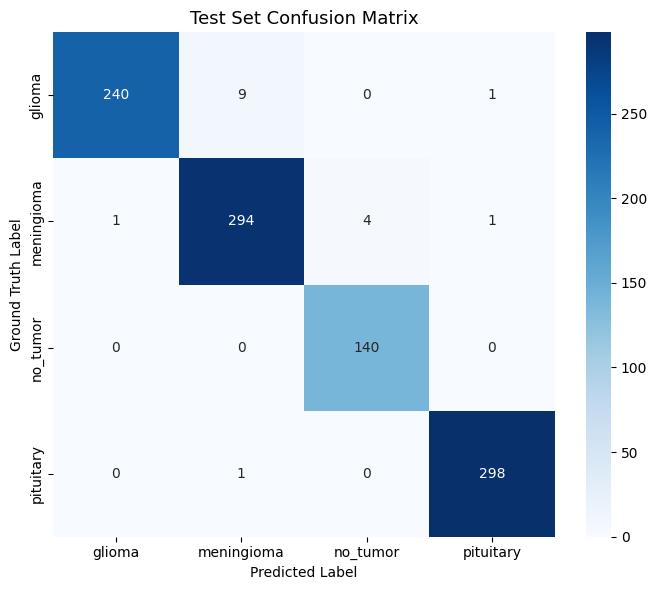

Confusion matrix saved to: /content/drive/MyDrive/medboard/weights/confusion_matrix.png


In [7]:
from modules.clf_trainer import evaluate
import torch.nn as nn
import seaborn as sns

print('Evaluating best model on un-seen Test Set (1,000 images)...')
criterion = nn.CrossEntropyLoss()
device = torch.device(DEVICE_STR)

# Safeguard: reload model if session disconnected
if 'model' not in locals():
    from modules.classifier import build_classifier
    model = build_classifier(num_classes=len(DEFAULT_CLASSES), pretrained=False).to(device)
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    print(f'Model reloaded from: {CHECKPOINT_PATH}')

test_metrics = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    class_names=DEFAULT_CLASSES,
)

print('\n' + '=' * 60)
print(f'TEST ACCURACY:  {test_metrics["accuracy"] * 100:.2f}%')
print(f'TEST MACRO-F1:  {test_metrics["macro_f1"]:.4f}')
print(f'TEST LOSS:      {test_metrics["loss"]:.4f}')
print('=' * 60)

print('\nDetailed Classification Report:')
print(test_metrics['classification_report'])

# Plot Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(
    test_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=DEFAULT_CLASSES,
    yticklabels=DEFAULT_CLASSES,
)
plt.title('Test Set Confusion Matrix', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('Ground Truth Label')
plt.tight_layout()

cm_path = os.path.join(WEIGHTS_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=200)
plt.show()
print(f'Confusion matrix saved to: {cm_path}')

## Cell 8 — Export Weights for MedBoard Pipeline

In [8]:
# Copy best checkpoint to final release weights
if os.path.exists(CHECKPOINT_PATH):
    shutil.copy2(CHECKPOINT_PATH, FINAL_PATH)
    print('Saved final weights to:', FINAL_PATH)
    print(f'File size: {os.path.getsize(FINAL_PATH) / (1024**2):.2f} MB')

if IS_COLAB:
    print('\nDownload `efficientnet_b0_brisc.pth` from your Google Drive:')
    print('  MyDrive/medboard/weights/efficientnet_b0_brisc.pth')
    print('And paste it into your local project at:')
    print('  d:\\Projects\\Major\\models\\classification\\efficientnet_b0_brisc.pth')
else:
    print('\nWeights are saved directly in your local models/classification folder.')

print('\nClassification model ready for Phase 3! ✅')

Saved final weights to: /content/drive/MyDrive/medboard/weights/efficientnet_b0_brisc.pth
File size: 15.59 MB

Download `efficientnet_b0_brisc.pth` from your Google Drive:
  MyDrive/medboard/weights/efficientnet_b0_brisc.pth
And paste it into your local project at:
  d:\Projects\Major\models\classification\efficientnet_b0_brisc.pth

Classification model ready for Phase 3! ✅


## Cell 9 — Save Classification Metrics JSON & Report


In [10]:
import json
from sklearn.metrics import classification_report

# Generate per-class dictionary report
report_dict = classification_report(
    test_metrics['targets'],
    test_metrics['predictions'],
    target_names=DEFAULT_CLASSES,
    output_dict=True,
    zero_division=0,
)

clf_metrics = {
    'model': 'EfficientNet-B0',
    'architecture': 'EfficientNet-B0 (Pretrained on ImageNet)',
    'dataset': 'BRISC 2025 (Kaggle)',
    'parameters': int(count_parameters(model)['total']),
    'num_classes': len(DEFAULT_CLASSES),
    'classes': DEFAULT_CLASSES,
    'test_samples': len(test_metrics['targets']),
    'training': {
        'epochs_ran': len(history['train_loss']),
        'best_val_acc': round(float(max(history['val_acc'])), 4),
        'best_val_f1': round(float(max(history['val_f1'])), 4),
        'final_train_loss': round(float(history['train_loss'][-1]), 4),
        'final_train_acc': round(float(history['train_acc'][-1]), 4),
        'learning_rate': 1e-4,
        'lr_scheduler': 'cosine',
    },
    'metrics': {
        'test_loss': round(float(test_metrics['loss']), 4),
        'test_accuracy': round(float(test_metrics['accuracy']), 4),
        'test_accuracy_percentage': round(float(test_metrics['accuracy']) * 100, 2),
        'test_macro_f1': round(float(test_metrics['macro_f1']), 4),
        'test_macro_f1_percentage': round(float(test_metrics['macro_f1']) * 100, 2),
    },
    'per_class_metrics': {
        cls_name: {
            'precision': round(float(report_dict[cls_name]['precision']), 4),
            'recall': round(float(report_dict[cls_name]['recall']), 4),
            'f1_score': round(float(report_dict[cls_name]['f1-score']), 4),
            'support': int(report_dict[cls_name]['support']),
        }
        for cls_name in DEFAULT_CLASSES
    },
    'confusion_matrix': test_metrics['confusion_matrix'].tolist(),
}

# 1. Save JSON metrics
clf_json_path = os.path.join(WEIGHTS_DIR, 'classification_metrics.json')
with open(clf_json_path, 'w') as f:
    json.dump(clf_metrics, f, indent=2)
print(f'Metrics JSON saved to: {clf_json_path}')

# 2. Save text classification report
clf_txt_path = os.path.join(WEIGHTS_DIR, 'classification_report.txt')
with open(clf_txt_path, 'w') as f:
    f.write(test_metrics['classification_report'])
print(f'Text report saved to:   {clf_txt_path}')

print('\nStructured Summary:')
print(json.dumps(clf_metrics['metrics'], indent=2))

Metrics JSON saved to: /content/drive/MyDrive/medboard/weights/classification_metrics.json
Text report saved to:   /content/drive/MyDrive/medboard/weights/classification_report.txt

Structured Summary:
{
  "test_loss": 0.0719,
  "test_accuracy": 0.9828,
  "test_accuracy_percentage": 98.28,
  "test_macro_f1": 0.983,
  "test_macro_f1_percentage": 98.3
}
